# Learning Unit 4: Image Registration
This exercise introduces the **key concepts of image registration.**

The aim is to spatially align to or more images, that means we want to deform them to "look alike". This has many applications in computer vision and medical imaging.
- 1) The first step is to define the spatial transformation and a cost function (image similarity metric)
- 2) Next we implement an optimisation loop that registers two images at a time.
- 3) Finally, we see how we can train a convolutional network on a given dataset that can subsquently be used to quickly align unseen images.

We will work with the well-known MNIST digit dataset and also use some medical brain images (MRI slices).

In [ ]:
#import required libraries
!pip install monai
!pip install wget
import torch
import torch.nn as nn
import torch.nn.functional as F
import monai
import wget
import imageio.v3 as iio
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision
import nibabel as nib
from tqdm.notebook import trange,tqdm
import os
torch.set_float32_matmul_precision('high')
device = 'cpu'
if(torch.cuda.is_available()):
    os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
    os.environ['CUDA_VISIBLE_DEVICES'] = str(0)
    print(torch.cuda.get_device_name())
    device = 'cuda'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 22.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=db81bb27b9e89a855b2985ca19bcbe2ffb10bd1dcc91f0f0bbe75252ee8dc9f3
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


100%|██████████| 9.91M/9.91M [00:00<00:00, 40.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.18MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.87MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.73MB/s]


shape of data tensor torch.Size([5421, 1, 32, 32])


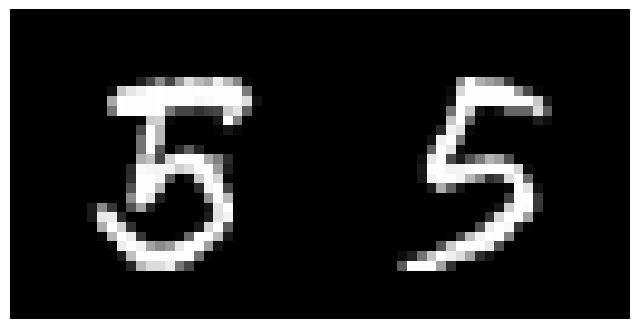

In [ ]:
#read and visualise a pair of digits
mnist = torchvision.datasets.mnist.MNIST('./',download=True)
mnist5 = F.pad(mnist.data[mnist.targets==5].float().div(255).unsqueeze(1),(2,2,2,2))
print('shape of data tensor',mnist5.shape)
plt.rcParams['figure.figsize'] = (8,5)
moving = mnist5[400:401].data
fixed = mnist5[600:601].data

plt.imshow(torch.cat((moving[0,0],fixed[0,0]),1),'gray')
plt.axis('off')
plt.show()

To define a **2D spatial transformation** we need a grid of size BxHxWx2, where B=batch size, H=height, W=width and 2 is the number of dimensions.

In pytorch the coordinates start from (-1,-1) left-top corner and go towards (+1,+1) right-bottom corner.

In ``torch.nn.functional`` there are two imporant functions ``F.affine_grid`` and ``F.grid_sample`` take a few minutes to familiarise yourself with their usage by looking up the pytorch documentation. The following example applies a random affine (linear) transformation to one of the input images.

tensor([[[-0.2713, -0.1012,  0.1343],
         [-0.2008, -0.2156, -0.0641]]])


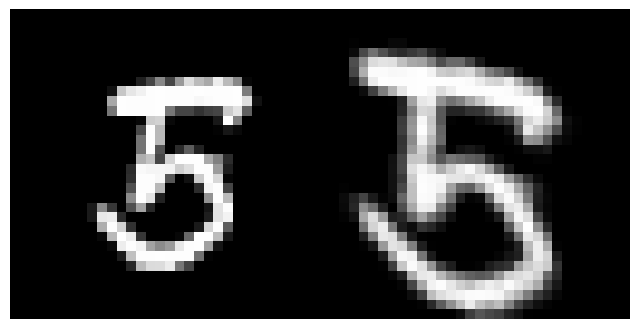

In [ ]:
#example for random affine transform
torch.manual_seed(400)
affine_target = torch.randn(1,2,3)*.15
print(affine_target)
affine_grid = F.affine_grid(torch.eye(2,3).unsqueeze(0)+affine_target,(1,1,32,32),align_corners=False)
target = F.grid_sample(moving,affine_grid,align_corners=False).data
plt.imshow(torch.cat((moving[0,0],target[0,0]),1),'gray')
plt.axis('off')
plt.show()

Our first attempt at image registration will be to find this same random affine transformation using optimisation.

Your task is the following:
- 1) create a tensor ``affine_estimate`` of zeros with shape 1x2x3 that has ``requires_grad=True`` and pass it as a list (that means in square brackets) to an optimiser > ``torch.optim.Adam`` with learning rate ``lr=0.01``
- 2) add this tensor to the identity matrix ``torch.eye(2,3).unsqueeze(0)`` to create a new affine grid that adapts throughout iterations
- 2) put everything into the standard optimisation loop with 250 iterations using zero_grad, loss computation, backward and optimizer.step
- 3) call F.grid_sample and use the ``nn.MSELoss()`` as metric between the target and your transformed moving image

The resulting ``torch.norm()`` between ``affine_target`` and ``affine_estimate`` should be reduced from 0.44 to <2e-6

  0%|          | 0/250 [00:00<?, ?it/s]

norm 0.43912750482559204 > 1.8208402252639644e-06


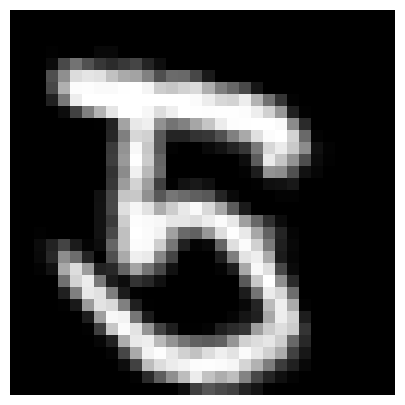

In [ ]:
#todo
affine_estimate = torch.zeros(1,2,3, requires_grad=True) #todo
optimizer = torch.optim.Adam([affine_estimate],lr=0.01)
for i in trange(250):
    optimizer.zero_grad()
    #next three lines are todo
    affine_grid = F.affine_grid(torch.eye(2,3).unsqueeze(0)+affine_estimate,(1,2,32,32), align_corners=False)
    transformed_moving = F.grid_sample(moving, affine_grid,align_corners=False)
    loss = F.mse_loss(target, transformed_moving)
    loss.backward()
    optimizer.step()
print('norm',affine_target.norm().item(),'>',(affine_estimate-affine_target).norm().item())
plt.imshow(transformed_moving[0,0].data,'gray')
plt.axis('off')
plt.show()

Since affine transformations cannot capture local deformations we will now extend our model to estimate one displacement vector per pixel. That means we optimise the tensor that describes the whole grid ``displacement_field`` and not just a matrix that creates a transform.

Predicting a vector for each pixel creates an ill-posed problem, which may lead to undesirable solutions. The resulting transformation should be spatially smooth. For this reason we need a second loss term called regularisation. It should penalise the gradient of both displacement components. In addition, we want to put the focus on low-frequency deformations and hence introduce a low-pass B-spline filter.

Briefly familiarise yourself with the concept of B-spline smoothing as e.g. explained at Wikipedia:
A cardinal B-spline has uniformly spaced knots, therefore interpolation between the knots equals convolution with a smoothing kernel. Example, if we want to interpolate three values in between B-spline nodes
**b**,  we can write the signal as $\mathbf {x} =[\mathbf {b} _{1},0,0,\mathbf {b} _{2},0,0,\mathbf {b} _{3},0,0,\dots ,\mathbf {b} _{n},0,0].$
Convolution of the signal
$\mathbf {x}$ with a rectangle function $\mathbf {h} =[1/3,1/3,1/3]$ gives first order interpolated B-spline values. Second-order B-spline interpolation is convolution with a rectangle function twice
$\mathbf {y} =\mathbf {x} *\mathbf {h} *\mathbf {h}$; by iterative filtering with a rectangle function, higher-order interpolation is obtained.

Fast B-spline interpolation on a uniform sample domain can be done by iterative mean-filtering. This can be implemented in pytorch as follows. Use the builtin ``F.avg_pool2d`` with ``kernel=7`` and ``padding=3`` (half the kernel width). Importantly you also have to set the argument ``stride=1`` to avoid unwanted downsampling. In this exercise we want to use a quadratic B-spline that comprises two ``avg_pool2d`` operations. In the example below a cubic B-spline is applied to a random input.

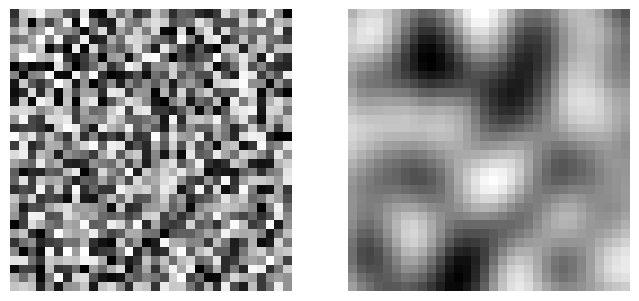

In [ ]:
#example
torch.manual_seed(400)
rand_im = torch.rand(1,1,48,48)
smooth_im = F.avg_pool2d(F.avg_pool2d(F.avg_pool2d(rand_im,5,stride=1,padding=2),5,stride=1,padding=2),5,stride=1,padding=2).squeeze()[8:-8,8:-8]
f,ax = plt.subplots(1,2)
ax[0].imshow(rand_im.squeeze()[8:-8,8:-8],'gray'); ax[0].axis('off')
ax[1].imshow(smooth_im,'gray'); ax[1].axis('off')
plt.show()

Next we also want to introduce a spatial regularisation that encourages the network to predict plausible and smooth transformations. The simplest option is the diffusion regulariser that is based on the squared norm of the x- and y-gradients of x- and y-displacements. Obtaining a spatial gradient can be easily achieved by shifting a tensor by one before subtracting it from itself. E.g. ``grad = moving[0,0] - torch.roll(moving[0,0],1,1)``
For the displacement field we need to do this for both *channels* (x- and y-displacement) and the two spatial dimensions (here 1 and 2).  

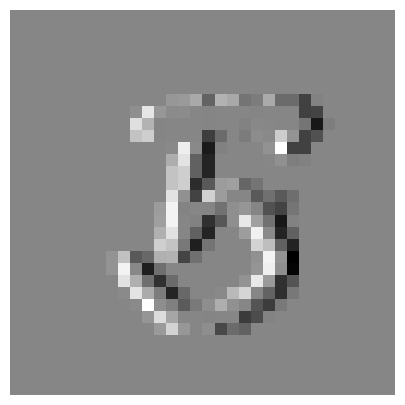

In [ ]:
grad = moving[0,0] - torch.roll(moving[0,0],1,1)
plt.imshow(grad,'gray')
plt.axis('off'); plt.show()

For the implementation of a deformable image registration. You can follow very similar steps as before. Since, the displacements are relative to the unchanged image coordinates we start by defining an ``identity`` transform using ``torch.eye(2,3)`` and ``F.affine_grid`` as before. Next, we create a tensor that contains the optimisable displacements, initialised as zeros, with a shape of $1\times 32\times 32\times 2$ and ``requires_grad`` enabled.

Note, that the spatial dimensions are now 1 and 2 and the channels are last. To apply the aforementioned B-spline using ``avg_pool2d`` we need to firstly bring the channels to dim=1 using ``.permute(0,3,1,2)`` and afterwards put them back to dim=3 using ``.permute(0,2,3,1)``. The B-spline transform is then applied (with the addition of ``identity`` to the moving image as before. But the loss is extended by adding ``mean()`` of the ``square()`` of the spatial gradients, which can be obtained with ``torch.roll`` as explained above. Optionally, the regulariser can be weighted with a $\lambda$ - here set to 1.

If everything is correctly implemented you should see a result as precomputed and shown in this cell.


--2026-06-11 19:37:45--  https://cloud.imi.uni-luebeck.de/s/ngC56K7kRa4D6mQ/download
Resolving cloud.imi.uni-luebeck.de (cloud.imi.uni-luebeck.de)... 141.83.20.118
Connecting to cloud.imi.uni-luebeck.de (cloud.imi.uni-luebeck.de)|141.83.20.118|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://cloud.imi.uni-luebeck.de/public.php/dav/files/ngC56K7kRa4D6mQ/?accept=zip [following]
--2026-06-11 19:37:46--  https://cloud.imi.uni-luebeck.de/public.php/dav/files/ngC56K7kRa4D6mQ/?accept=zip
Reusing existing connection to cloud.imi.uni-luebeck.de:443.
HTTP request sent, awaiting response... 200 OK
Length: 7608 (7.4K) [application/zip]
Saving to: ‘reg_result_opt.zip’

reg_result_opt.zip  100%[===================>]   7.43K  --.-KB/s    in 0s      

2026-06-11 19:37:46 (106 MB/s) - ‘reg_result_opt.zip’ saved [7608/7608]

Archive:  reg_result_opt.zip
  inflating: reg_result_opt_flow.png  
  inflating: reg_result_opt_overlay.png  


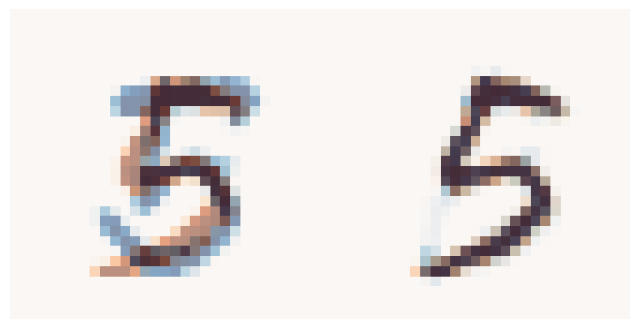

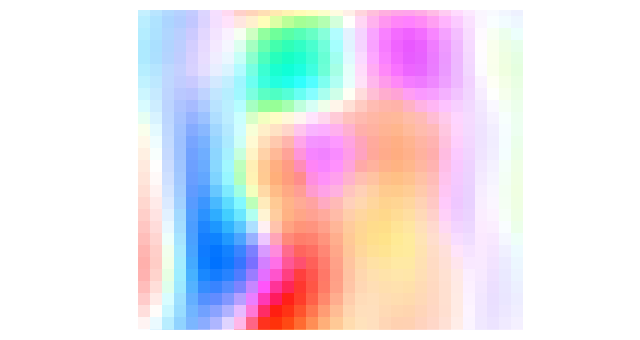

In [ ]:
!wget https://cloud.imi.uni-luebeck.de/s/ngC56K7kRa4D6mQ/download -O reg_result_opt.zip
!unzip -o reg_result_opt.zip
if(os.path.exists('reg_result_opt_overlay.png')):
    plt.imshow(iio.imread('reg_result_opt_overlay.png')[100:-100,100:-100]); plt.axis('off'); plt.show()
if(os.path.exists('reg_result_opt_flow.png')):
    plt.imshow(iio.imread('reg_result_opt_flow.png')[90:-90,90:-90]); plt.axis('off'); plt.show()

  0%|          | 0/250 [00:00<?, ?it/s]

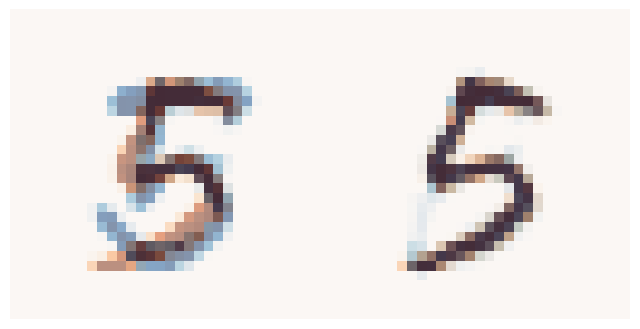

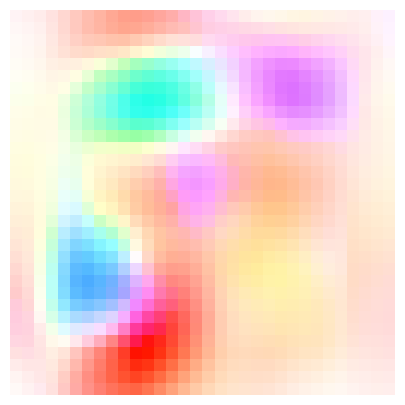

In [ ]:
#todo
identity = torch.eye(2,3).unsqueeze(0)

identity_grid = F.affine_grid(
        identity,
        (1,1,32,32),
        align_corners=False
    )

displacement_field = torch.zeros((1,32,32,2), requires_grad=True)
optimizer = torch.optim.Adam([displacement_field],lr=0.01)

#hyperparameters and loops given
lambda_weight = 1; kernel = 7; half_width = (kernel-1)//2
for i in trange(250):
    optimizer.zero_grad()

    #todo

    displacement_field1 = F.avg_pool2d(
        F.avg_pool2d(
          displacement_field.permute(0,3,1,2),
          kernel_size=kernel,
          stride=1,
          padding=half_width
          ),
    kernel_size=kernel,
    stride=1,
    padding=half_width
    ).permute(0,2,3,1)




    transformed_moving = F.grid_sample(
        moving,
        displacement_field1+identity_grid,
        align_corners=False
    )
    loss = F.mse_loss(transformed_moving, fixed )

    dx = displacement_field1 - torch.roll(displacement_field1, 1, dims=2)
    dy = displacement_field1 - torch.roll(displacement_field1, 1, dims=1)

    #grad2 = (smooth_disp[0,0] - torch.roll(smooth_disp[0,0],1,1)).square().mean()
    grad2 = dx.square().mean() + dy.square().mean()
    loss += lambda_weight * grad2

    loss.backward()
    optimizer.step()


#visualisation given
plt.imshow(torch.cat((fixed[0,0],fixed[0,0]),1),'Oranges')
plt.imshow(torch.cat((moving[0,0],transformed_moving[0,0].data),1),'Blues',alpha=0.5)
plt.axis('off')
#plt.savefig('reg_result_opt_overlay.png')
plt.show()
flow_field = torchvision.utils.flow_to_image(displacement_field1[0].permute(2,0,1)).permute(1,2,0)
plt.imshow(flow_field)
plt.axis('off')
#plt.savefig('reg_result_opt_flow.png')
plt.show()


Now we can start implementing our registration network using  architectures from ``monai`` to ease the process. The module itself should be based on ``AutoEncoder``, which comprises a convolutional encoder ``.encode`` to map each mini-batch of fixed or moving images separately into a feature tensor of shape ``B x 128 x 4 x 4``:
``embedded = self.network.encode(fixed_batch)-self.network.encode(moving_batch)``

The result of both inputs are subtracted and fed into the deconvolutional decoder ``.decode`` that combines the information and predicts the displacements (the ``tanh`` contrains the maximum displacement):
``torch.tanh(self.network.decode(embedded))*.25``

This approach has a desirable symmetry to it and can be trained robustly. However, many other published methods work slightly differently in that they concatenate the channels of fixed and moving images at the beginning and use a normal U-Net with skip connections.

In [ ]:
import monai
from monai.networks.nets.autoencoder import AutoEncoder


The model should be implemented as a derived class from nn.Module, which follows the following structure
```
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 20, 5)
        self.conv2 = nn.Conv2d(20, 20, 5)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        return F.relu(self.conv2(x))
```
Here the modules/layers containing trainable parameters and potentially some hyperparamaters are fixed at initialisation ``__init__()`` whereas the actual implementation is put into the ``forward()`` method. Note that ``forward`` has only access to variables and layers that are defined within the context ``self.`` in ``__init__``.   

Use the following parameters for ``Autoencoder``: ``spatial_dims=2,in_channels=1,out_channels=2`` and`` channels=(8,32,64,128),strides=(1,2,2,2)``.  The ``__init__`` method should be callable with two user definable arguments ``kernel`` for the B-spline smoothing and ``lambda_weight`` for the diffusion regulariser. The forward path is otherwise equivalent to the solution of the previous task and should return three arguments ``transformed_moving, displacement_field1, loss``.
The training procedure for your model is provided in the following cell and should run in less than a minute (also locally on CPU) and visualise both the aligned images and the optical flow field. If interested you can find further information on optical flow at https://pytorch.org/vision/stable/auto_examples/others/plot_optical_flow.html#sphx-glr-auto-examples-others-plot-optical-flow-py.

In [ ]:

class RegistrationModel(nn.Module):
    def __init__(self,kernel,lambda_weight):
        super().__init__()
        self.network = AutoEncoder(spatial_dims=2,in_channels=1,out_channels=2,channels=(8,32,64,128), strides=(1,2,2,2)) #todo
        self.kernel = kernel
        self.lambda_weight = lambda_weight
    def forward(self, fixed_batch, moving_batch):
        lambda_weight = self.lambda_weight; kernel = self.kernel;
        half_width = (kernel-1)//2
        B,C,H,W = fixed_batch.shape
        embedded = self.network.encode(fixed_batch)-self.network.encode(moving_batch)
        identity = F.affine_grid(torch.eye(2,3).unsqueeze(0).repeat(B,1,1),(B,1,H,W), align_corners=False)
        displacement_field = torch.tanh(self.network.decode(embedded))*.25
        #todo
        displacement_field1 = F.avg_pool2d(
          F.avg_pool2d(
              displacement_field,
              kernel_size=kernel,
              stride=1,
              padding=half_width
            ),
          kernel_size=kernel,
          stride=1,
          padding=half_width
          ).permute(0,2,3,1)



        transformed_moving = F.grid_sample(
        moving_batch,
        displacement_field1+identity,
        align_corners=False
        )

        if not hasattr(self, "_printed_shapes"):
          print("fixed:", fixed_batch.shape)
          print("embedded:", embedded.shape)
          print("displacement:", displacement_field.shape)
          self._printed_shapes = True
        loss = F.mse_loss(transformed_moving, fixed_batch )

        dx = displacement_field1 - torch.roll(displacement_field1, 1, dims=2)
        dy = displacement_field1 - torch.roll(displacement_field1, 1, dims=1)

        grad2 = dx.square().mean() + dy.square().mean()
        loss += lambda_weight * grad2


        return transformed_moving,displacement_field1,loss

  0%|          | 0/500 [00:00<?, ?it/s]

torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 32, 32])
torch.Size([24, 2, 3

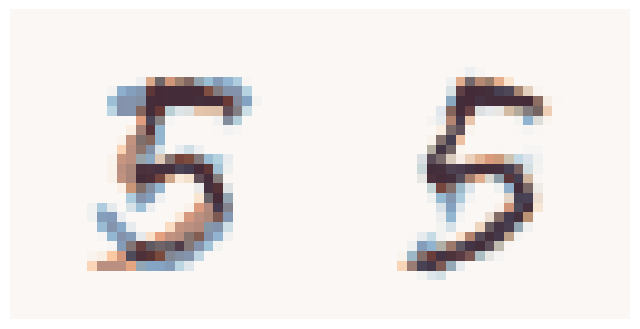

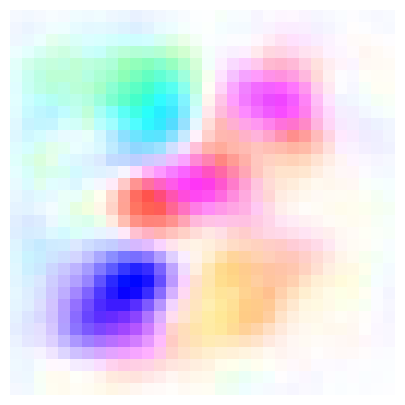

In [ ]:
lambda_weight = 5; kernel = 3;
network = RegistrationModel(kernel = 3,lambda_weight = 5).to(device)
optimizer = torch.optim.Adam(network.parameters(),lr=0.001)
iters = 500
run_loss = torch.zeros(iters)
for i in trange(iters):
    optimizer.zero_grad()
    idx_rand = torch.randperm(len(mnist5)-512)[:48]
    if(i==iters-1):
        idx_rand[0] = 600; idx_rand[24] = 400 #re-created same example
    fixed_batch = mnist5[idx_rand[:24]]
    moving_batch = mnist5[idx_rand[24:]]
    transformed_moving,displacement_field1,loss = network(fixed_batch.to(device),moving_batch.to(device))
    loss.backward()
    optimizer.step()
    run_loss[i] = loss.item()

plt.imshow(torch.cat((fixed_batch[0,0],fixed_batch[0,0]),1).cpu(),'Oranges')
plt.imshow(torch.cat((moving_batch[0,0].cpu(),transformed_moving[0,0].cpu().data),1),'Blues',alpha=0.5)
plt.axis('off')
plt.show()
flow_field = torchvision.utils.flow_to_image(displacement_field1[0].float().data.cpu().permute(2,0,1)).permute(1,2,0)
plt.imshow(flow_field)
plt.axis('off')
plt.show()

it is important to note that while this trained registration model will generalise to new unseen images that are similar in shape, e.g. other "5"-digits it won't necessarily work perfectly on "3"s.

/tmp/ipykernel_16109/3163060900.py:12: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  identity = F.affine_grid(torch.eye(2,3).unsqueeze(0).repeat(B,1,1),(B,1,H,W))


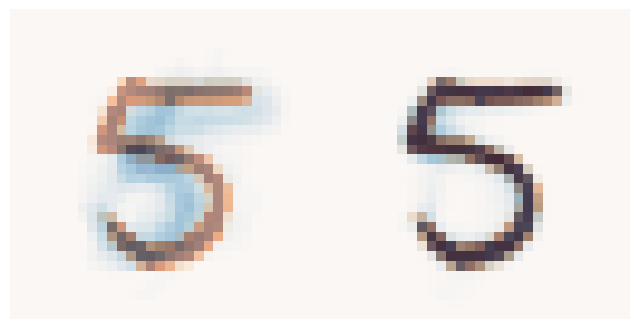

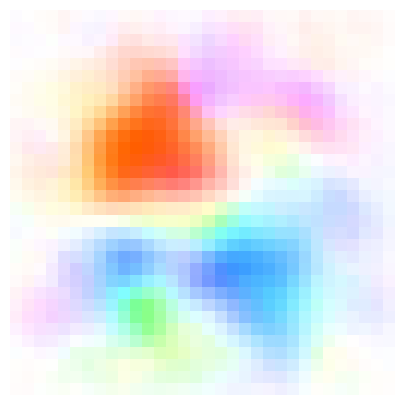

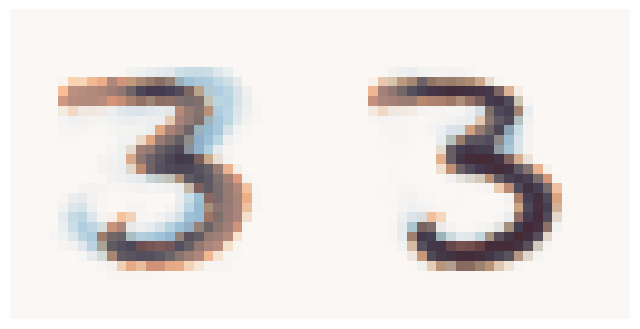

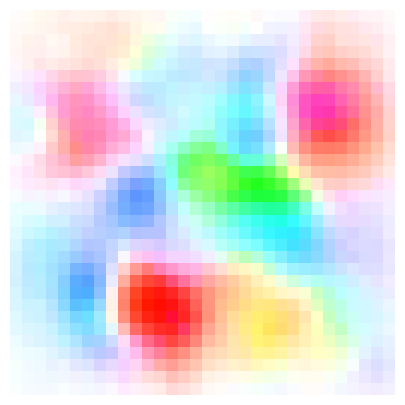

In [ ]:
with torch.no_grad():
    idx_rand = torch.arange(48)+len(mnist5)-512
    idx_rand[:24] = len(mnist5)-512+3
    fixed_batch = mnist5[idx_rand[:24]]
    moving_batch = mnist5[idx_rand[24:]]
    transformed_moving,displacement_field1,_ = network(fixed_batch.to(device),moving_batch.to(device))


plt.imshow(torch.cat((fixed_batch[0,0],fixed_batch[0,0]),1).cpu(),'Oranges')
plt.imshow(torch.cat((moving_batch[:,0].mean(0).cpu(),transformed_moving[:,0].mean(0).cpu().data),1),'Blues',alpha=0.5)
plt.axis('off')
plt.show()
flow_field = torchvision.utils.flow_to_image(displacement_field1[0].float().data.cpu().permute(2,0,1)).permute(1,2,0)
plt.imshow(flow_field)
plt.axis('off')
plt.show()

mnist3 = F.pad(mnist.data[mnist.targets==3].float().div(255).unsqueeze(1),(2,2,2,2))
with torch.no_grad():
    idx_rand = torch.arange(48)
    idx_rand[:24] = 2
    fixed_batch = mnist3[idx_rand[:24]].to(device)
    moving_batch = mnist3[idx_rand[24:]].to(device)
    transformed_moving,displacement_field1,_ = network(fixed_batch.to(device),moving_batch.to(device))

plt.imshow(torch.cat((fixed_batch[0,0],fixed_batch[0,0]),1).cpu(),'Oranges')
plt.imshow(torch.cat((moving_batch[:,0].mean(0).cpu(),transformed_moving[:,0].mean(0).cpu().data),1),'Blues',alpha=0.5)
plt.axis('off')
plt.show()
flow_field = torchvision.utils.flow_to_image(displacement_field1[0].float().data.cpu().permute(2,0,1)).permute(1,2,0)
plt.imshow(flow_field)
plt.axis('off')
plt.show()

Finally, we want to apply the same model to MRI brain data. We download a simplified 2D (toy) dataset from our collaborators at Harvard MGH. The images are mid brain slices from the public OASIS collection with semantic segmentation labels for 24 different regions, which are the following: Left-Cerebral-White-Matter, Left-Cerebral-Cortex, Left-Lateral-Ventricle, Left-Inf-Lat-Ventricle, Left-Thalamus, Left-Caudate, Left-Putamen, Left-Pallidum, 3rd-Ventricle, Brain-Stem, Left-Hippocampus, Left-Ventral-DC, Left-Choroid-Plexus, Right-Cerebral-White-Matter, Right-Cerebral-Cortex, Right-Lateral-Ventricle, Right-Inf-Lat-Ventricle, Right-Thalamus, Right-Caudate, Right-Putamen, Right-Pallidum, Right-Hippocampus, Right-Ventral-DC, Right-Choroid-Plexus.


In [ ]:
dataset_url = 'https://surfer.nmr.mgh.harvard.edu/ftp/data/neurite/data/neurite-oasis.2d.v1.0.tar'

def get_data(data_url):
    filename = './neurite-oasis.2d.v1.0.tar'
    if not os.path.exists(filename):
        wget.download(data_url)
        !mkdir "neurite-oasis2d/"
        !tar -xvf "neurite-oasis.2d.v1.0.tar" -C "neurite-oasis2d/"


get_data(dataset_url)
print()

README.md
seg24_labels.txt
seg35_labels.txt
seg4_labels.txt
subjects.txt
OASIS_OAS1_0001_MR1/slice_norm.nii.gz
OASIS_OAS1_0001_MR1/slice_orig.nii.gz
OASIS_OAS1_0001_MR1/slice_seg24.nii.gz
OASIS_OAS1_0001_MR1/slice_seg4.nii.gz
OASIS_OAS1_0002_MR1/slice_norm.nii.gz
OASIS_OAS1_0002_MR1/slice_orig.nii.gz
OASIS_OAS1_0002_MR1/slice_seg24.nii.gz
OASIS_OAS1_0002_MR1/slice_seg4.nii.gz
OASIS_OAS1_0003_MR1/slice_norm.nii.gz
OASIS_OAS1_0003_MR1/slice_orig.nii.gz
OASIS_OAS1_0003_MR1/slice_seg24.nii.gz
OASIS_OAS1_0003_MR1/slice_seg4.nii.gz
OASIS_OAS1_0004_MR1/slice_norm.nii.gz
OASIS_OAS1_0004_MR1/slice_orig.nii.gz
OASIS_OAS1_0004_MR1/slice_seg24.nii.gz
OASIS_OAS1_0004_MR1/slice_seg4.nii.gz
OASIS_OAS1_0005_MR1/slice_norm.nii.gz
OASIS_OAS1_0005_MR1/slice_orig.nii.gz
OASIS_OAS1_0005_MR1/slice_seg24.nii.gz
OASIS_OAS1_0005_MR1/slice_seg4.nii.gz
OASIS_OAS1_0006_MR1/slice_norm.nii.gz
OASIS_OAS1_0006_MR1/slice_orig.nii.gz
OASIS_OAS1_0006_MR1/slice_seg24.nii.gz
OASIS_OAS1_0006_MR1/slice_seg4.nii.gz
OASIS_OAS

In [ ]:

img_oasis = []
seg_oasis = []
for i in trange(500):
    file = 'neurite-oasis2d/OASIS_OAS1_0'+str(i).zfill(3)+'_MR1/slice_norm.nii.gz'
    file_seg = 'neurite-oasis2d/OASIS_OAS1_0'+str(i).zfill(3)+'_MR1/slice_seg24.nii.gz'
    if(os.path.exists(file)):
        img_oasis.append(torch.from_numpy(nib.load(file).get_fdata()).float().squeeze().t())
        seg_oasis.append(torch.from_numpy(nib.load(file_seg).get_fdata()).float().squeeze().t())

#OASIS_OAS1_0102_MR1/slice_seg24.nii.gz
img_oasis = torch.stack(img_oasis).unsqueeze(1).to(device)
seg_oasis = torch.stack(seg_oasis).unsqueeze(1).to(device)


  0%|          | 0/500 [00:00<?, ?it/s]

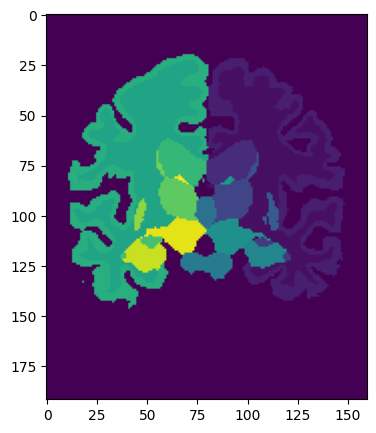

In [ ]:
plt.imshow(img_oasis[0,0].cpu(),'gray')
plt.imshow(seg_oasis[0,0].cpu(),alpha=.5*(seg_oasis[0,0].cpu()>0).float())
plt.show()

In [ ]:
#evaluate dice before/after
def dice_coeff(outputs, labels, max_label):
    B,_,_ = labels.shape
    dice = torch.FloatTensor(B,max_label-1).fill_(0)
    for label_num in range(1, max_label):
        iflat = (outputs==label_num).view(B,-1).float()
        tflat = (labels==label_num).view(B,-1).float()
        intersection = torch.mean(iflat * tflat)
        dice[:,label_num-1] = (2. * intersection) / (1e-8 + torch.mean(iflat) + torch.mean(tflat))
    return dice


We use the Dice coefficient of the anatomical regions as a proxy to measure registration quality. Note, that corresponding landmarks would be preferable and measuring overlap of too large structures is sometimes not very meaningful (https://pubmed.ncbi.nlm.nih.gov/21827972/). The initial value for the first random 24 registration pairs is 50.53%. Next you can simply re-train the same registration module and use the provided code to evaluate its quality. Since, the images are larger it will take slightly longer (up to 6 minutes). If you work on a MacBook you can push the images and network to 'mps' but need to use 'cpu' for the grid_sample operations, which reduces the time to 1.5 minutes. The resulting Dice should improve to approx. 65% and a better alignment should be visually observable.

In [ ]:
d = dice_coeff(seg_oasis[idx_rand[:24],0].long(),seg_oasis[idx_rand[24:],0].long(),25)
print(d.mean())

tensor(0.5053)


  0%|          | 0/500 [00:00<?, ?it/s]

fixed: torch.Size([24, 1, 192, 160])
embedded: torch.Size([24, 128, 24, 20])
displacement: torch.Size([24, 2, 192, 160])


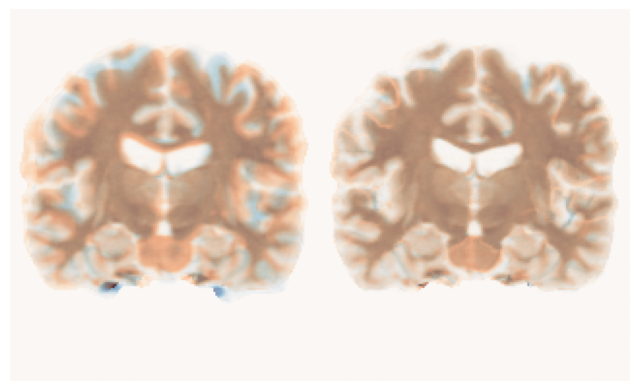

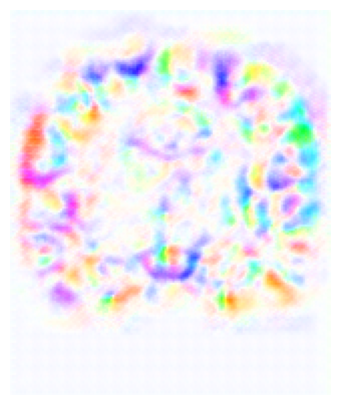

In [ ]:
#lambda_weight = 5; kernel = 3; half_width = (kernel-1)//2
#takes 6 minutes on CPU and .5-1.5 minutes on GPU
network = RegistrationModel(kernel = 3,lambda_weight = 5).to(device)

optimizer = torch.optim.Adam(network.parameters(),lr=0.001)
iters = 500
run_loss = torch.zeros(iters)
for i in trange(iters):
    optimizer.zero_grad()
    idx_rand = torch.randperm(380)[:48]
    if(i==iters-1):
        idx_rand[0:24] = 380; idx_rand[24:] = torch.arange(381,381+24) #left-out for validation
    fixed_batch = img_oasis[idx_rand[:24]]
    moving_batch = img_oasis[idx_rand[24:]]
    transformed_moving,displacement_field1,loss = network(fixed_batch.to(device),moving_batch.to(device))

    loss.backward()
    optimizer.step()
    run_loss[i] = loss.item()

plt.imshow(torch.cat((fixed_batch[0,0],fixed_batch[0,0]),1).cpu(),'Oranges')
plt.imshow(torch.cat((moving_batch[0,0],transformed_moving[0,0].data),1).cpu(),'Blues',alpha=0.5)
plt.axis('off')
plt.show()
flow_field = torchvision.utils.flow_to_image(displacement_field1[0].float().data.cpu().permute(2,0,1)).permute(1,2,0)
plt.imshow(flow_field)
plt.axis('off')
plt.show()

In [ ]:
B,_,H,W = seg_oasis[idx_rand[24:]].shape
identity = F.affine_grid(torch.eye(2,3).unsqueeze(0).to(device).repeat(B,1,1),(B,1,H,W),align_corners=False)
print(displacement_field1[0,100,100])
print(identity[0,100,100])
print((identity + displacement_field1)[0,100,100])
transformed_seg_moving = F.grid_sample(seg_oasis[idx_rand[24:]],identity+displacement_field1,align_corners=False,mode='nearest')

d = dice_coeff(seg_oasis[idx_rand[:24],0].long(),transformed_seg_moving[:,0].long(),25)
print(d.mean())

tensor([0.0058, 0.0040], grad_fn=<SelectBackward0>)
tensor([0.2563, 0.0469])
tensor([0.2621, 0.0509], grad_fn=<SelectBackward0>)
tensor(0.6473)


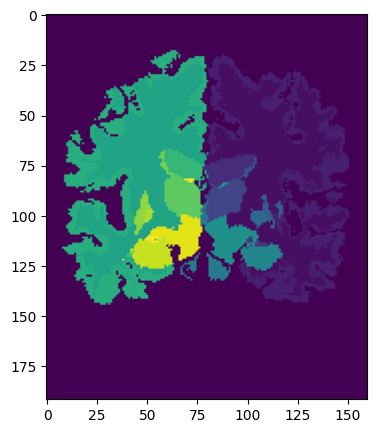

tensor([0.7986, 0.6663, 0.9017, 0.0920, 0.8326, 0.5676, 0.5231, 0.4737, 0.7188,
        0.8722, 0.7509, 0.8639, 0.2610, 0.8443, 0.6596, 0.9248, 0.1489, 0.8752,
        0.6735, 0.5832, 0.4779, 0.8030, 0.8779, 0.3456])


In [ ]:
plt.imshow(img_oasis[idx_rand[0],0].cpu(),'gray')
plt.imshow(transformed_seg_moving[0,0].cpu().data,alpha=.35*(transformed_seg_moving[0,0].cpu().data>0).float())
plt.show()
print(d[-1])